# SAUVC YOLO11n training on Kaggle

Fine-tune a pretrained **YOLO11n detector** for `flag`, `gate`, `flare`, and `bucket`.
This notebook prints training and validation losses every 5 epochs (configurable),
saves every epoch's metrics, and plots **all numeric columns in the training log**.

**Before running:** attach your dataset, enable a GPU accelerator and Internet in Kaggle,
then run the cells in order. Internet is used for installing packages and downloading
pretrained weights. The code uses one GPU so the notebook's custom callback is preserved.

Your dataset configuration is sufficient to write this code. The actual images/labels
were not supplied, so dataset quality, size, and model accuracy have not been assessed.
Training has not been run on your dataset.

Expected paths, relative to the dataset root:

| Split | Images | Matching labels |
|---|---|---|
| Train | `images/train` | `labels/train` |
| Validation | `images/valid` | `labels/valid` |
| Test (optional final evaluation) | `images/test` | `labels/test` |

An image such as `images/train/frame001.jpg` matches `labels/train/frame001.txt`.
Each label row is `class_id x_center y_center width height`, with normalized coordinates
and IDs **0=flag, 1=gate, 2=flare, 3=bucket**. Empty or absent label files are valid only
for images with no target objects. This notebook expects detection boxes, not polygons.

Avoid splitting adjacent frames of the same video across train/validation/test.
Hold out entire recording sessions where possible.


In [1]:
# Run before importing ultralytics. If Kaggle requests a restart, restart and rerun.
%pip install -q "ultralytics>=8.3.0,<9" pandas matplotlib pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 7.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Settings and GPU

Leave `DATASET_ROOT = None` to search attached datasets for the supplied layout.
If several datasets match, set it to the full folder containing `images` and `labels`.
The original relative `path: yolo_dataset_v2` is replaced with that absolute path.

`EPOCHS` is a maximum: early stopping may finish sooner. If GPU memory runs out,
reduce `BATCH` to 8 or 4. Normal Ultralytics progress output still appears each epoch;
`PRINT_EVERY` controls the additional compact train/validation summaries.


In [4]:
import csv
import json
import math
import platform
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import distributions

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.data.utils import IMG_FORMATS
from IPython.display import display, Image

DATASET_ROOT = "/kaggle/input/datasets/kushagrajaveri/mantaclaus-sauvc-2026-yolo-dataset/yolo_dataset_v2/yolo_dataset_v2"  
# Example: "/kaggle/input/my-dataset/yolo_dataset_v2"
CLASS_NAMES = ["flag", "gate", "flare", "bucket"]
MODEL_WEIGHTS = "yolo11n.pt"
EPOCHS = 100
IMAGE_SIZE = 640
BATCH = 16
PRINT_EVERY = 5
PATIENCE = 25
RUN_TEST = False  # Change only when ready for a final held-out test evaluation.

WORK = Path("/kaggle/working")
WORK.mkdir(parents=True, exist_ok=True)
assert torch.cuda.is_available(), "Enable a GPU accelerator in Kaggle, then rerun."
assert PRINT_EVERY >= 1 and EPOCHS >= 1 and BATCH >= 1
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Ultralytics: {ultralytics.__version__}; PyTorch: {torch.__version__}")

# Avoid external experiment-tracker sign-in prompts.
for key in ("wandb", "comet", "clearml", "mlflow", "neptune", "dvc", "raytune"):
    if key in settings:
        settings.update({key: False})


GPU: Tesla T4
Ultralytics: 8.4.157; PyTorch: 2.10.0+cu128


## 2. Resolve the dataset and check annotations

The table reports object instances per class, not just image counts. Missing classes
and possible background images are reported for you to review. Ultralytics performs
its own image decoding and additional dataset checks when training starts.


In [5]:
def resolve_dataset_root(override=None):
    def matches(root):
        return all((root / "images" / split).is_dir() for split in ("train", "valid"))

    if override is not None:
        root = Path(override).expanduser().resolve()
        if not matches(root):
            raise FileNotFoundError(f"Expected images/train and images/valid inside {root}")
        return root

    candidates = sorted({
        p.parent.resolve() for p in Path("/kaggle/input").rglob("images")
        if p.is_dir() and matches(p.parent)
    })
    preferred = [p for p in candidates if p.name == "yolo_dataset_v2"]
    choices = preferred or candidates
    if len(choices) != 1:
        raise ValueError(
            "Set DATASET_ROOT to the full folder containing images and labels. "
            f"Matching roots: {[str(p) for p in choices]}"
        )
    return choices[0]


def inspect_split(root, split):
    image_dir = root / "images" / split
    label_dir = root / "labels" / split
    images = sorted(p for p in image_dir.rglob("*")
                    if p.is_file() and p.suffix.lower().lstrip(".") in IMG_FORMATS)
    if not images or not label_dir.is_dir():
        raise FileNotFoundError(f"Need images in {image_dir} and labels in {label_dir}")

    counts = [0] * len(CLASS_NAMES)
    missing, empty = 0, 0
    used_labels = set()
    for image_path in images:
        label = label_dir / image_path.relative_to(image_dir).with_suffix(".txt")
        if label in used_labels:
            raise ValueError(f"Multiple images map to the same label: {label}")
        used_labels.add(label)
        if not label.exists():
            missing += 1
            continue
        lines = [line for line in label.read_text().splitlines() if line.strip()]
        if not lines:
            empty += 1
        for line_number, line in enumerate(lines, 1):
            try:
                values = [float(value) for value in line.split()]
                assert len(values) == 5 and all(math.isfinite(v) for v in values)
                cls, x, y, w, h = values
                assert cls.is_integer() and 0 <= cls < len(CLASS_NAMES)
                assert 0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1
            except (ValueError, AssertionError) as exc:
                raise ValueError(f"Invalid YOLO box at {label}, line {line_number}: {line}") from exc
            counts[int(cls)] += 1

    if not sum(counts):
        raise ValueError(f"No labelled target objects found in {split}; check your annotations.")
    absent = [name for name, count in zip(CLASS_NAMES, counts) if count == 0]
    if absent:
        print(f"Review {split}: no labelled instances of {absent}.")
    if missing or empty:
        print(f"Review {split}: {missing} missing and {empty} empty label files. "
              "These images must contain no unlabelled target objects.")
    return {"split": split, "images": len(images), "missing_labels": missing,
            "empty_labels": empty, **dict(zip(CLASS_NAMES, counts))}


ROOT = resolve_dataset_root(DATASET_ROOT)
print("Dataset root:", ROOT)
summary = pd.DataFrame([inspect_split(ROOT, split) for split in ("train", "valid")])
display(summary)

data_config = {
    "path": str(ROOT), "train": "images/train", "val": "images/valid",
    "nc": len(CLASS_NAMES), "names": CLASS_NAMES,
}
if (ROOT / "images/test").is_dir():
    data_config["test"] = "images/test"
DATA_YAML = WORK / "sauvc_data.yaml"
DATA_YAML.write_text(yaml.safe_dump(data_config, sort_keys=False))
print(DATA_YAML.read_text())


Dataset root: /kaggle/input/datasets/kushagrajaveri/mantaclaus-sauvc-2026-yolo-dataset/yolo_dataset_v2/yolo_dataset_v2
Review train: 0 missing and 678 empty label files. These images must contain no unlabelled target objects.
Review valid: 0 missing and 78 empty label files. These images must contain no unlabelled target objects.


,split,images,missing_labels,empty_labels,flag,gate,flare,bucket
0,train,5547,0,678,1030,1375,1510,3599
1,valid,1253,0,78,162,544,379,774


path: /kaggle/input/datasets/kushagrajaveri/mantaclaus-sauvc-2026-yolo-dataset/yolo_dataset_v2/yolo_dataset_v2
train: images/train
val: images/valid
nc: 4
names:
- flag
- gate
- flare
- bucket
test: images/test



## 3. Print losses after each chosen epoch and train

Validation runs **every epoch**. The callback prints at epoch 1, every `PRINT_EVERY`
epochs, and the last epoch (including early stopping). It reads the completed epoch's
CSV row after validation and ignores the repeated callback from final best-model evaluation.

YOLO11 reports three loss components: **box** (box localization), **cls** (class prediction),
and **dfl** (bounding-box refinement). `sum` below is the sum of those logged components
for monitoring, not the batch-scaled scalar used for backpropagation. Lower losses are
generally better, but training augmentation and validation conditions differ; evaluate
detection quality with validation precision, recall, and mAP as well.


In [6]:
def make_loss_reporter(every=5):
    last_seen_epoch = 0

    def report(trainer):
        nonlocal last_seen_epoch
        csv_path = Path(trainer.csv)
        if not csv_path.exists():
            return
        with csv_path.open(newline="") as handle:
            row = None
            for record in csv.DictReader(handle):
                row = {key.strip(): value for key, value in record.items()}
        if row is None:
            return
        epoch = int(float(row["epoch"]))
        if epoch <= last_seen_epoch:
            return
        last_seen_epoch = epoch
        is_last = bool(getattr(trainer, "stop", False)) or epoch >= trainer.epochs
        if epoch != 1 and epoch % every != 0 and not is_last:
            return

        parts = ("box_loss", "cls_loss", "dfl_loss")
        train = [float(row[f"train/{part}"]) for part in parts]
        val = [float(row[f"val/{part}"]) for part in parts]
        detail = lambda values: ", ".join(
            f"{name}={value:.4f}" for name, value in zip(("box", "cls", "dfl"), values)
        )
        print(
            f"\n[Epoch {epoch}/{trainer.epochs}] "
            f"train(sum)={sum(train):.4f} ({detail(train)}) | "
            f"val(sum)={sum(val):.4f} ({detail(val)}) | "
            f"mAP50={float(row['metrics/mAP50(B)']):.4f} | "
            f"mAP50-95={float(row['metrics/mAP50-95(B)']):.4f}",
            flush=True,
        )

    return report


model = YOLO(MODEL_WEIGHTS)
model.add_callback("on_fit_epoch_end", make_loss_reporter(PRINT_EVERY))

RUN_NAME = "sauvc_yolo11n_" + datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH,
    device=0,
    workers=2,
    optimizer="AdamW",
    lr0=0.001,
    patience=PATIENCE,
    seed=42,
    amp=True,
    val=True,
    plots=True,
    save=True,
    save_period=10,
    cache=False,
    project=str(WORK / "runs"),
    name=RUN_NAME,
    exist_ok=False,
)

RUN_DIR = Path(model.trainer.save_dir)
(WORK / "latest_sauvc_run.txt").write_text(str(RUN_DIR))
summary.to_csv(RUN_DIR / "dataset_summary.csv", index=False)
# Record versions for reproducibility without changing Kaggle's CUDA/PyTorch stack.
environment = {
    "python": platform.python_version(), "torch": torch.__version__,
    "ultralytics": ultralytics.__version__, "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
}
(RUN_DIR / "environment.json").write_text(json.dumps(environment, indent=2))
(RUN_DIR / "installed_packages.txt").write_text("\n".join(sorted(
    f"{dist.metadata['Name']}=={dist.version}" for dist in distributions()
    if dist.metadata.get("Name")
)))
print("Training outputs:", RUN_DIR)
print("Best weights:", RUN_DIR / "weights/best.pt")


Ultralytics 8.4.157 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sauvc_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sauvc_yolo11n_20260921_152952, nbs=64, nms

## 4. Plot the full training history

This plots every numeric logged column against epoch, pairing training/validation loss
components and adding a graph of their sums. It includes precision, recall, mAP50,
mAP50-95, learning rates, and elapsed time when present. These are actual recorded
values, with no smoothing. All metrics are also saved in `results.csv`.

`best.pt` is selected using Ultralytics' validation fitness, not necessarily the lowest
validation loss. `last.pt` contains the final epoch's weights. Ultralytics also saves
labelled training batches, validation predictions, and its standard diagnostic plots.


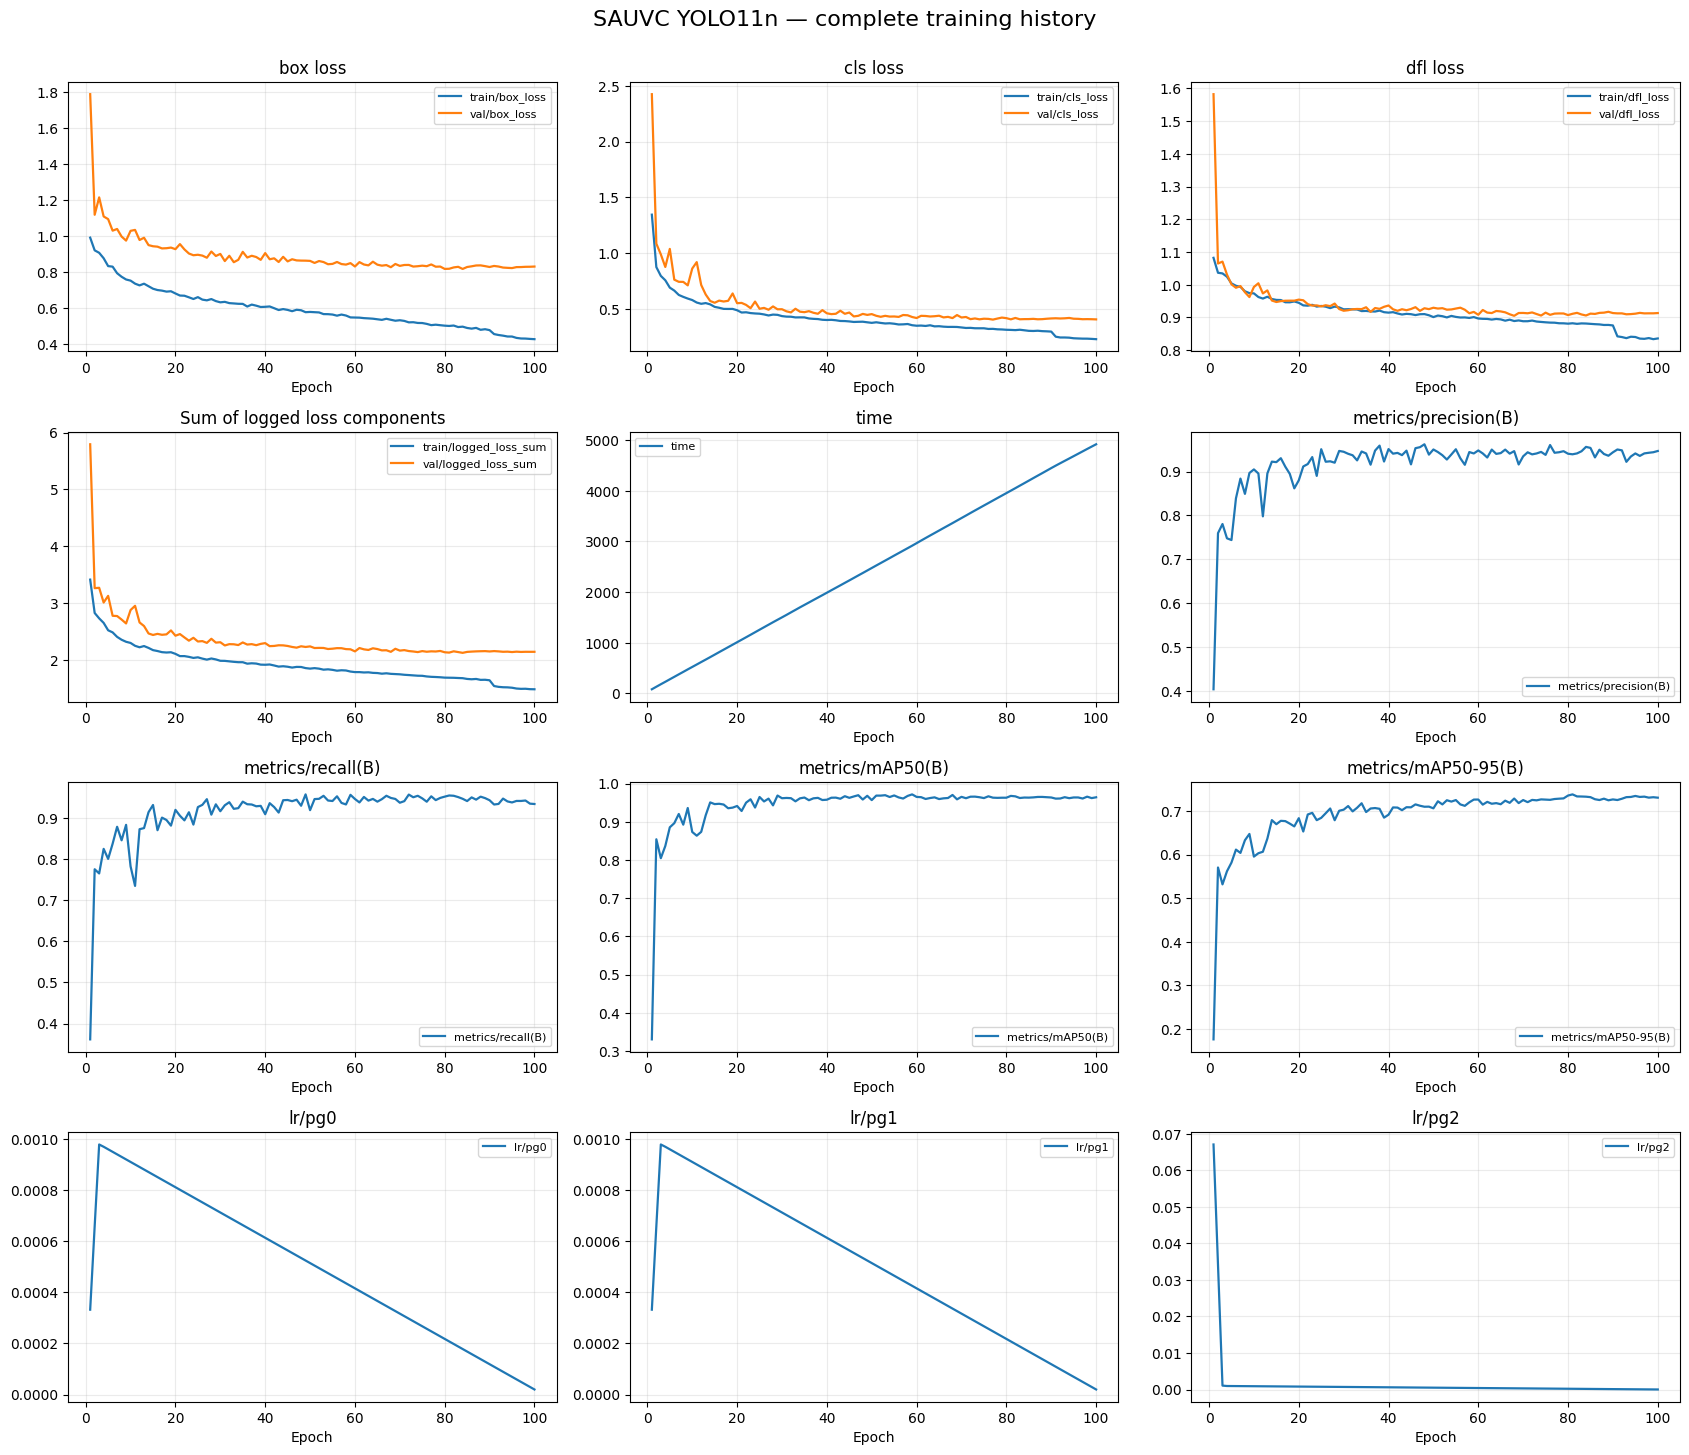

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train/logged_loss_sum,val/logged_loss_sum
95,96,4730.35,0.43483,0.23644,0.83519,0.93563,0.94224,0.96353,0.73233,0.82750,0.41220,0.91380,0.00006,0.00006,0.00006,1.50646,2.15350
96,97,4777.53,0.43161,0.23495,0.83445,0.94134,0.94220,0.96073,0.73301,0.82781,0.40889,0.91225,0.00005,0.00005,0.00005,1.50101,2.14895
97,98,4824.69,0.43112,0.23471,0.83679,0.94279,0.94326,0.96561,0.73070,0.82920,0.40967,0.91243,0.00004,0.00004,0.00004,1.50262,2.15130
98,99,4871.25,0.42923,0.23271,0.83343,0.94400,0.93562,0.96183,0.73166,0.82953,0.40888,0.91244,0.00003,0.00003,0.00003,1.49537,2.15085
99,100,4917.41,0.42779,0.23015,0.83561,0.94685,0.93479,0.96394,0.73062,0.83061,0.40734,0.91323,0.00002,0.00002,0.00002,1.49355,2.15118


All-metrics plot: /kaggle/working/runs/sauvc_yolo11n_20260921_152952/all_training_metrics.png
Raw epoch metrics: /kaggle/working/runs/sauvc_yolo11n_20260921_152952/results.csv


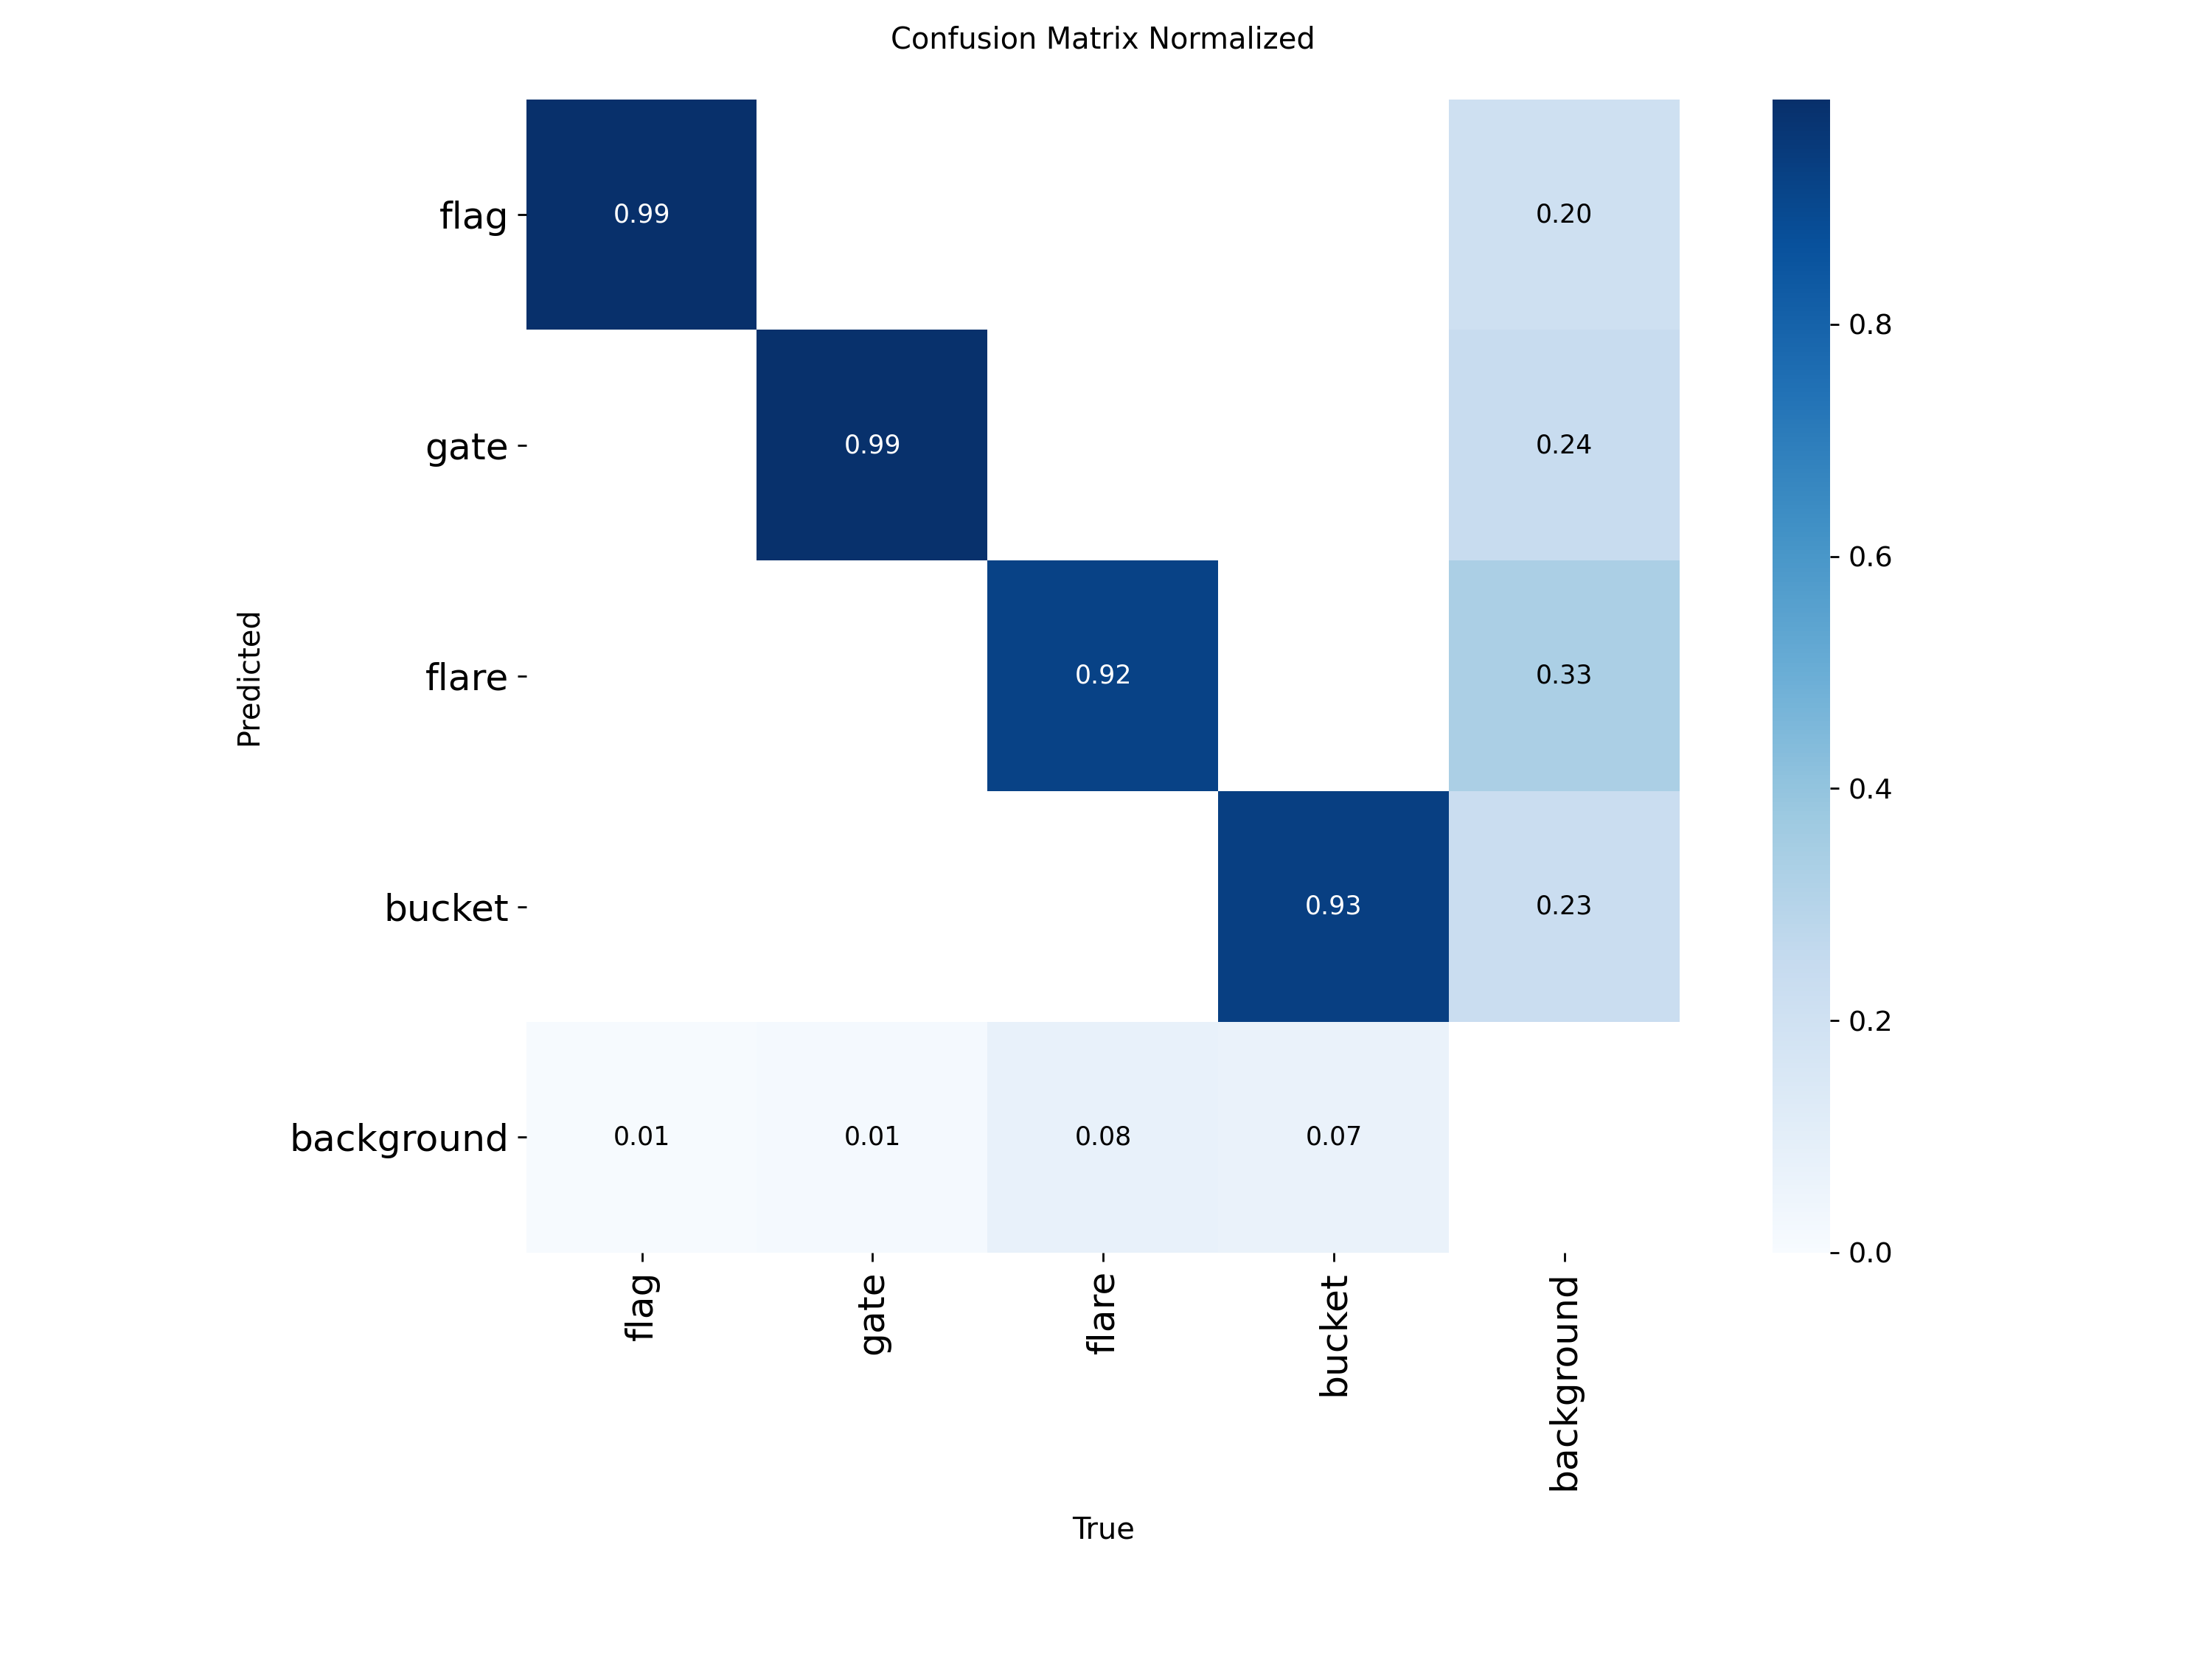

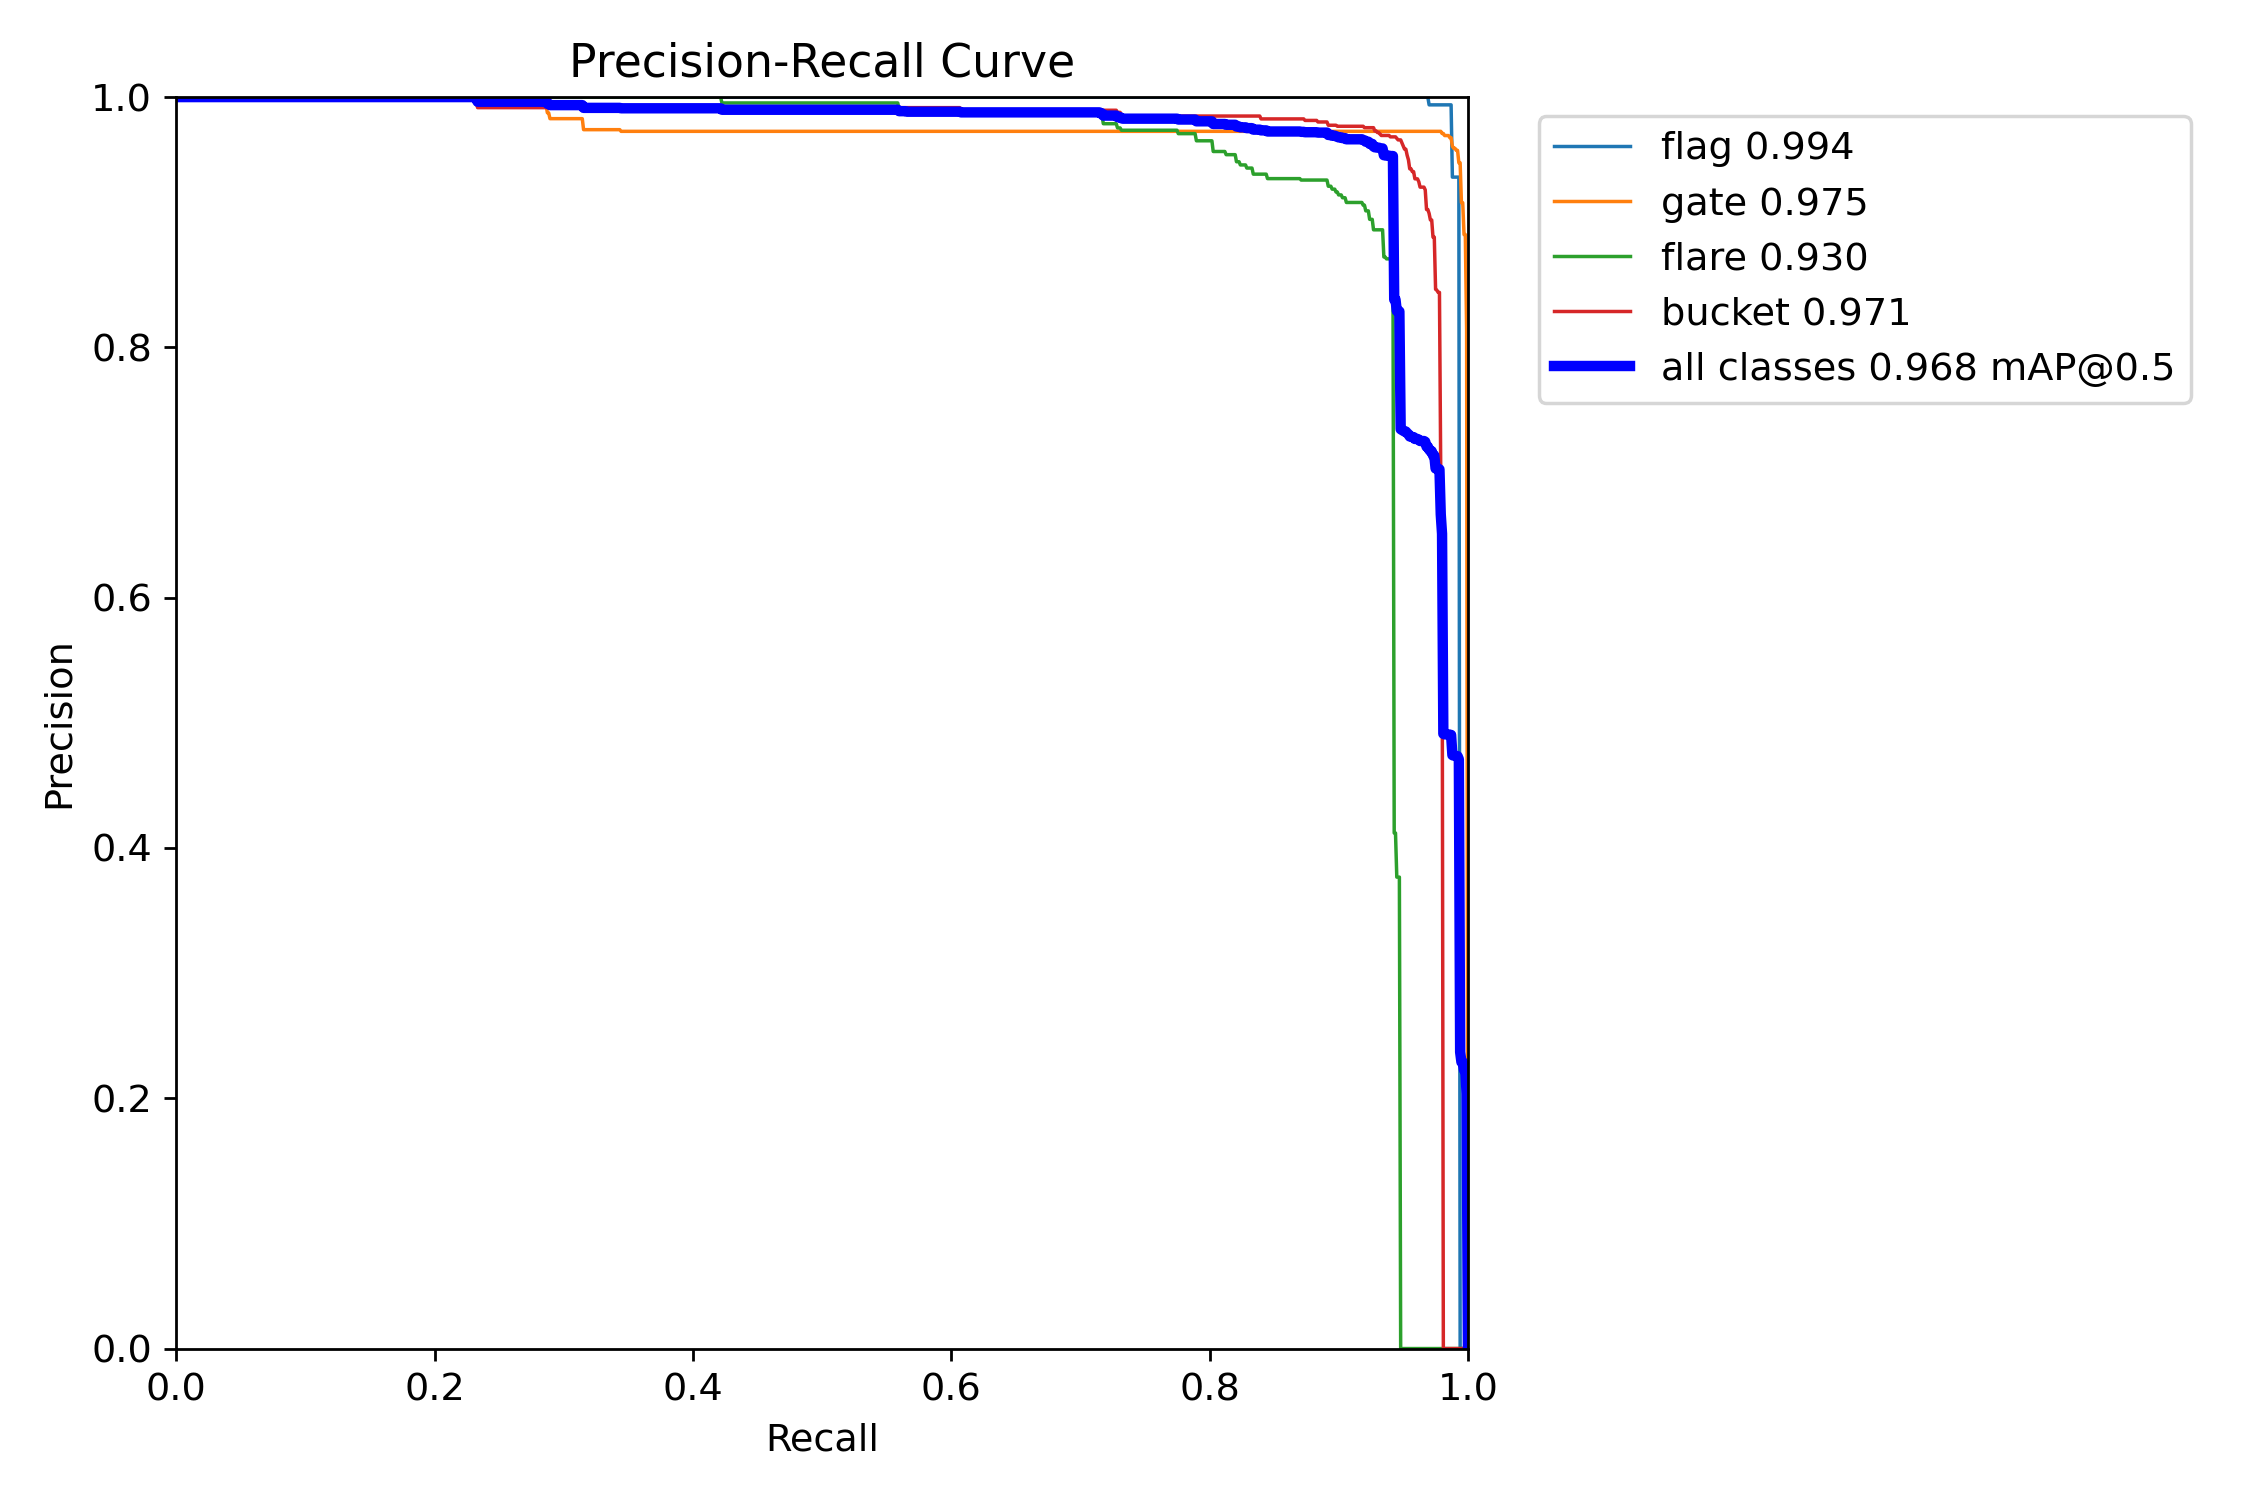

In [7]:
def plot_training_history(csv_path):
    history = pd.read_csv(csv_path)
    history.columns = history.columns.str.strip()
    history = history.apply(pd.to_numeric, errors="coerce")
    if history.empty or "epoch" not in history:
        raise ValueError("No completed training epochs found in results.csv")

    panels, covered = [], {"epoch"}
    components = ("box_loss", "cls_loss", "dfl_loss")
    for part in components:
        columns = [f"{split}/{part}" for split in ("train", "val")
                   if f"{split}/{part}" in history]
        if columns:
            panels.append((part.replace("_", " "), columns))
            covered.update(columns)

    sum_columns = []
    for split in ("train", "val"):
        columns = [f"{split}/{part}" for part in components]
        if all(column in history for column in columns):
            name = f"{split}/logged_loss_sum"
            history[name] = history[columns].sum(axis=1, min_count=len(columns))
            sum_columns.append(name)
    if sum_columns:
        panels.append(("Sum of logged loss components", sum_columns))
        covered.update(sum_columns)

    for column in history:
        if column not in covered and history[column].notna().any():
            panels.append((column, [column]))

    ncols = 3
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.7 * nrows), squeeze=False)
    for ax, (title, columns) in zip(axes.flat, panels):
        for column in columns:
            ax.plot(history["epoch"], history[column], label=column, linewidth=1.6)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    for ax in list(axes.flat)[len(panels):]:
        ax.set_visible(False)
    fig.suptitle("SAUVC YOLO11n — complete training history", fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    output = Path(csv_path).parent / "all_training_metrics.png"
    fig.savefig(output, dpi=160, bbox_inches="tight")
    plt.show()
    return history, output


# You can rerun this cell after training without retraining the model.
# For an interrupted run, first set RUN_DIR = Path("/kaggle/working/runs/your_run").
if "RUN_DIR" not in globals():
    RUN_DIR = Path((WORK / "latest_sauvc_run.txt").read_text().strip())
history, plot_path = plot_training_history(RUN_DIR / "results.csv")
display(history.tail())
print("All-metrics plot:", plot_path)
print("Raw epoch metrics:", RUN_DIR / "results.csv")

for filename in ("confusion_matrix_normalized.png", "BoxPR_curve.png", "PR_curve.png"):
    diagnostic = RUN_DIR / filename
    if diagnostic.exists():
        display(Image(filename=str(diagnostic), width=850))


In [8]:
import shutil
from IPython.display import FileLink, display

shutil.make_archive(
    "/kaggle/working/sauvc_results",
    "zip",
    root_dir="/kaggle/working/runs",
    base_dir="sauvc_yolo11n_20260921_152952",
)

display(FileLink("/kaggle/working/sauvc_results.zip"))

/kaggle/working/sauvc_results.zip

## 5. Optional final test-set evaluation

Leave `RUN_TEST=False` while comparing models or tuning settings. When the choices are
finished, change it to `True` and run this cell to evaluate `best.pt` on `images/test`.
Do not use test performance to repeatedly tune the model.


In [ ]:
if RUN_TEST:
    if "test" not in data_config:
        raise FileNotFoundError("No images/test folder was found in the dataset.")
    display(pd.DataFrame([inspect_split(ROOT, "test")]))
    best_model = YOLO(str(RUN_DIR / "weights/best.pt"))
    test_metrics = best_model.val(
        data=str(DATA_YAML), split="test", imgsz=IMAGE_SIZE, batch=BATCH,
        device=0, workers=2, plots=True,
        project=str(RUN_DIR), name="test_evaluation", exist_ok=False,
    )
    print(f"Test mAP50:    {test_metrics.box.map50:.4f}")
    print(f"Test mAP50-95: {test_metrics.box.map:.4f}")
    print("Test outputs:", test_metrics.save_dir)
else:
    print("Test set left untouched. Set RUN_TEST=True when ready for final evaluation.")

print("Download weights/best.pt, results.csv, all_training_metrics.png, and args.yaml from:")
print(RUN_DIR)


## Reading the results and using the model

- Falling training loss with worsening validation metrics can indicate overfitting.
- Inspect per-class performance and validation images, especially small or distant targets.
- Counts alone do not establish dataset sufficiency; camera conditions, session diversity,
  accurate labels, and representative held-out recordings matter.
- Save a Kaggle notebook version with its outputs before ending the session. Download
  `weights/best.pt` for deployment. Build a TensorRT engine on the Jetson later using its
  installed TensorRT stack, rather than copying a Kaggle-built engine.
- If a run is interrupted, the plotting function can read completed epochs from that run's
  `results.csv`. Set `RUN_DIR` manually if the post-training path marker was not written.

Documentation used: [YOLO11](https://docs.ultralytics.com/models/yolo11/),
[training options](https://docs.ultralytics.com/modes/train/),
[callbacks](https://docs.ultralytics.com/usage/callbacks/),
[YOLO detection labels](https://docs.ultralytics.com/datasets/detect/), and
[trainer callback ordering](https://docs.ultralytics.com/reference/engine/trainer/).

Notebook verification: code syntax, dataset checks, periodic reporting, and plotting were
checked with synthetic fixtures. No training run or model accuracy is claimed.
